In [ ]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt

from astroquery.gaia import Gaia

from gaiaunlimited import fetch_utils,utils
from gaiaunlimited import subsample

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [2]:
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"

# Optional: authenticate with your Gaia archive credentials
# so the result of the query are stored online.
Gaia.login(user='ktavan01', password='Sharksinthecc21!')

INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


In [6]:
inDict = {'healpix': 5,'phot_g_mean_mag': [3,20,0.2]}

In [7]:
%%time
subsampleSF = subsample.SubsampleSelectionFunction(subsample_query = "radial_velocity is not null",\
                                         file_name = 'dr3_lvl4',hplevel_and_binning = inDict)

INFO: Query finished. [astroquery.utils.tap.core]
CPU times: user 41 s, sys: 2.62 s, total: 43.6 s
Wall time: 11min 43s


/Users/Tavangar/anaconda3/envs/py311/lib/python3.11/site-packages/gaiaunlimited/selectionfunctions/subsample.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ds.dims.keys() - set(["ipix"]) == {"g", "c"}:
/Users/Tavangar/anaconda3/envs/py311/lib/python3.11/site-packages/gaiaunlimited/selectionfunctions/subsample.py:32: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  diff = set(ds["logitp"].dims) - ds.dims.keys()


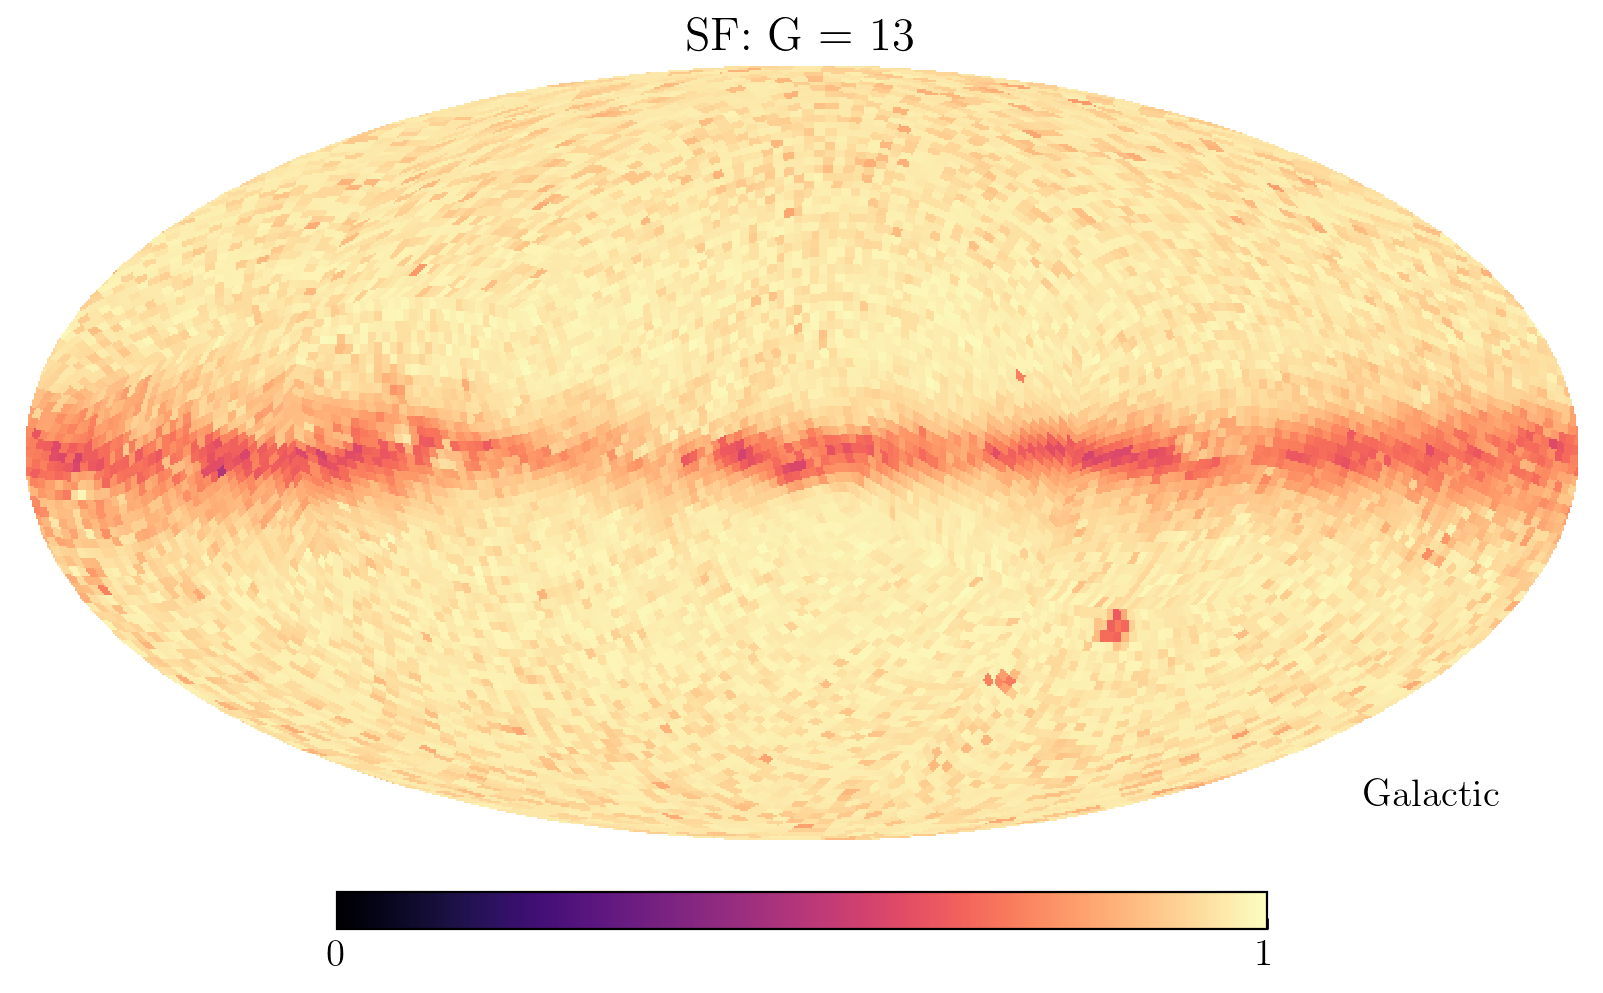

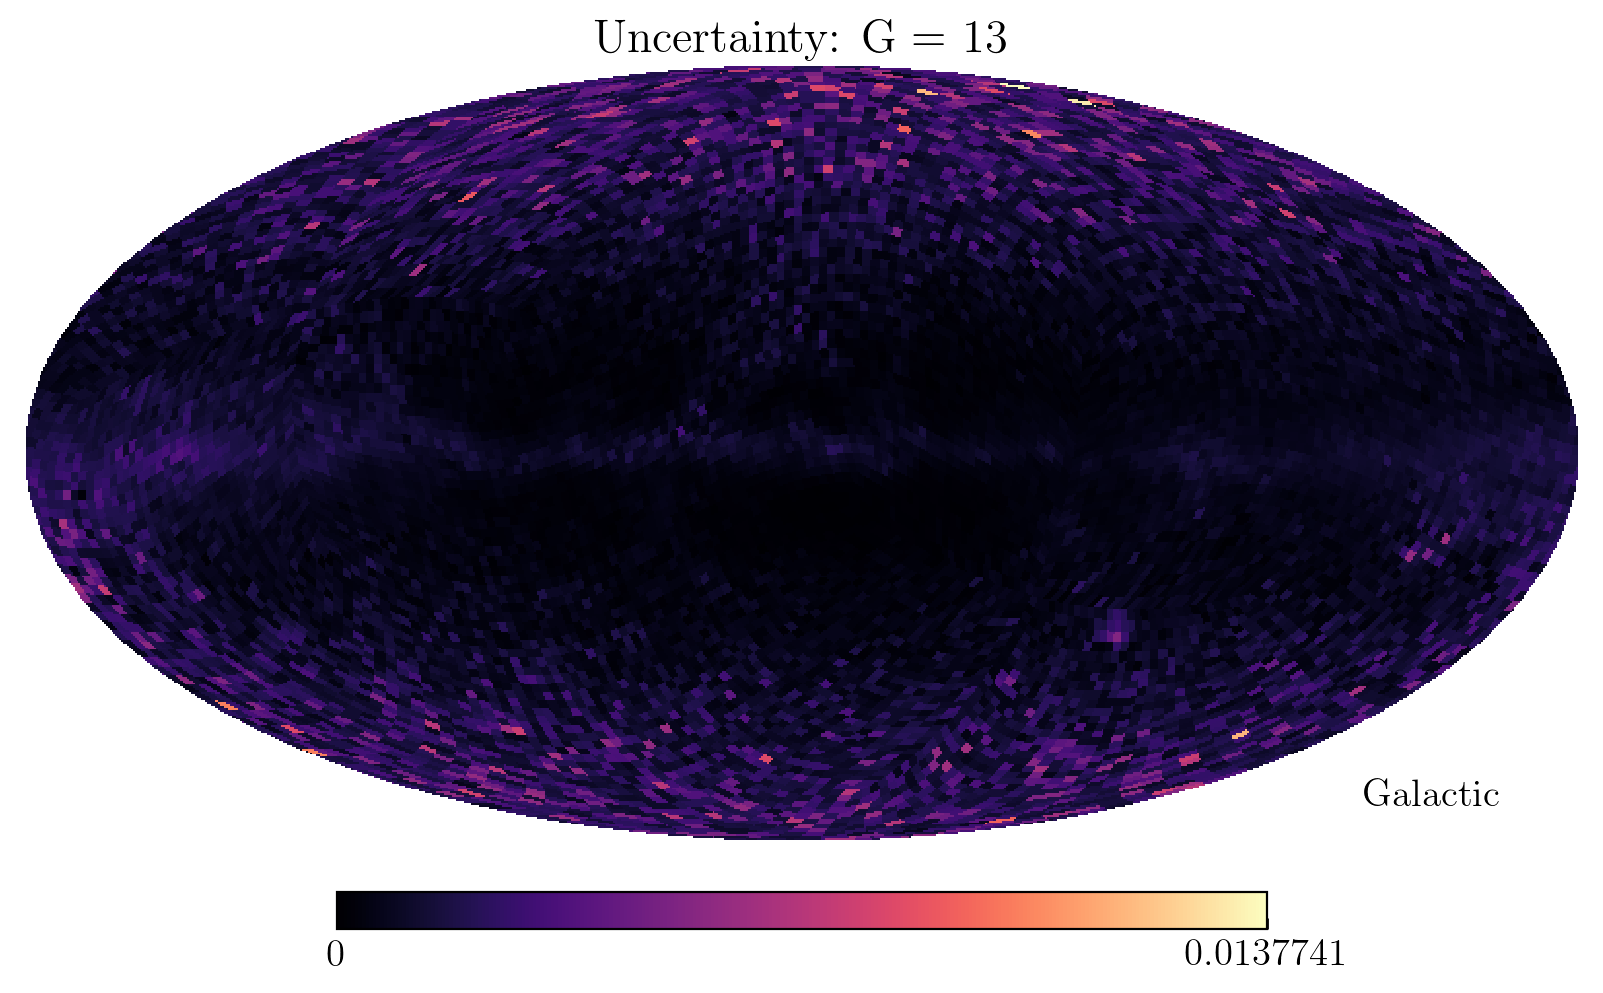

In [15]:
# Specify at which colour and magnitude
# you want to visualise the selection fraction:
G = 13

coords_of_centers = utils.get_healpix_centers(5)
gmag = np.ones_like(coords_of_centers) * G

subsample_SF_lvl4,var_lvl4 = subsampleSF.query(coords_of_centers,phot_g_mean_mag_ = gmag,
                                     return_variance = True,fill_nan = False)

plt.figure(figsize = (12,6))
hp.mollview(subsample_SF_lvl4,hold = True,min = 0,max = 1,title = 'SF: G = {}'.format(G),coord = 'CG')

plt.figure(figsize = (12,6))
hp.mollview(var_lvl4,hold = True,min = 0,title = 'Uncertainty: G = {}'.format(G),coord = 'CG')


In [ ]:
coords_of_centers

(12288,)